# Imports

In [2]:
import sys
import os
from os.path import sep
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
import seaborn as sns
import pandas as pd

# Local modules
sys.path.append('Documents{0}CEGIS{0}discsim{0}api{0}utils{0}Pre Survey Nested Simulation'.format(sep))
from AS_extract_data_from_dta_file import extract_data_from_dta
import ecd_nested_simulation_functions

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas


# NHFS-5

## Load data

In [3]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
file_path ='Documents{0}CEGIS{0}DiscSim_figures_and_data{0}NHFS-5 data{0}NHFS-5 data from SP - CORRECT COLUMN NAMES PR{0}IAPR7AFL.DTA'.format(sep)
data = extract_data_from_dta(file_path, convert_categoricals=False)

In [5]:
data

,hhid,hvidx,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,...,hml32b,hml32c,hml32d,hml32e,hml32f,hml32g,hml33,hml34,hml35,hml36
0,0100101305,1,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
1,0100101305,2,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2,0100101305,3,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
3,0100101305,4,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
4,0100101305,5,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843912,3700401592,1,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843913,3700401592,2,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843914,3700401592,3,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843915,3700401592,4,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN


Relevant column labels from .DO file:

label variable hc1      "Child's age in months"

label variable hc1a     "Child's age in days"

label variable hc2      "Child's weight in kilograms (1 decimal)"

label variable hc3      "Child's height in centimeters (1 decimal)"

label variable hc4      "Height/Age percentile"

label variable hc5      "Height/Age standard deviation"

label variable hc6      "Height/Age percent of ref. median"

label variable hc7      "Weight/Age percentile"

label variable hc8      "Weight/Age standard deviation"

label variable hc9      "Weight/Age percent of ref. median"

label variable hc10     "Weight/Height percentile"

label variable hc11     "Weight/Height standard deviation"

label variable hc12     "Weight/Height percent of ref. median"

label variable hc13     "Result of measurement - height/weight"

label variable hc15     "Height: lying or standing"

label variable hc27     "Sex"

## Processing

Values to exclude (from .DO file):

label define HC2     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC3     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC4     
  9998 "Flagged cases"
;

label define HC5     
  9998 "Flagged cases"
;

label define HC6     
 99998 "Flagged cases"
;

label define HC7     
  9998 "Flagged cases"
;

label define HC8     
  9998 "Flagged cases"
;

label define HC9     
 99998 "Flagged cases"
;

label define HC10    
  9998 "Flagged cases"
;

label define HC11    
  9998 "Flagged cases"
;

label define HC12    
 99998 "Flagged cases"
;


### Exclude rows with 'Not present', 'Refused', or 'Other' for height or weight

In [6]:
excl_values = [9994, 9995, 9996]
data.drop(data[(data['hc2'].isin(excl_values)) | (data['hc3'].isin(excl_values))].index, inplace=True)

### Exclude rows with 'Flagged cases' for HAP, WAP, HAZ, WAZ, WHP or WHZ

In [7]:
excl_values = [9998]
data.drop(data[(data['hc4'].isin(excl_values)) | (data['hc5'].isin(excl_values)) | (data['hc7'].isin(excl_values)) | (data['hc8'].isin(excl_values)) | (data['hc10'].isin(excl_values))].index, inplace=True)

### Exclude rows with NaN values for age, height or weight

In [8]:
# Drop rows with NaN for hc2, hc3 or hc1a
data.dropna(subset=['hc2', 'hc3', 'hc1a'], inplace=True)

## Get data into lists

In [9]:
age = data['hc1a']
weight = data['hc2']/10
height = data['hc3']/10
hap = data['hc4']
haz = data['hc5']/100
wap = data['hc7']
waz = data['hc8']/100
whp = data['hc10']
whz = data['hc11']/100
lohr = data['hc15'] # Whether height measured lying or standing
sex = data['hc27']


In [8]:
# Print minimum, maximum, mean and standard deviation of age, height, weight, haz, waz and whz.
print("Age: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(age), np.max(age), np.mean(age), np.std(age)))
print("Height: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(height), np.max(height), np.mean(height), np.std(height)))
print("Weight: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(weight), np.max(weight), np.mean(weight), np.std(weight)))
print("HAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(haz), np.max(haz), np.mean(haz), np.std(haz)))
print("WAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(waz), np.max(waz), np.mean(waz), np.std(waz)))
print("WHZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(whz), np.max(whz), np.mean(whz), np.std(whz)))


Age: Min = 0.0, Max = 1826.0, Mean = 936.9287669172933, Std = 523.0499086232693
Height: Min = 49.0, Max = 135.2, Mean = 84.51542556390979, Std = 13.753392069974018
Weight: Min = 1.9, Max = 30.3, Mean = 10.94460952380952, Std = 3.3320809525122224
HAZ: Min = -6.0, Max = 6.0, Mean = -1.209155008702718, Std = 1.6290267063420423
WAZ: Min = -5.98, Max = 5.98, Mean = -1.4485813817007167, Std = 1.2298998894575413
WHZ: Min = -4.0, Max = 6.0, Mean = -0.8721085213032584, Std = 1.2670488106121853


## Plot data and fitted normal distributions

HAZ Distribution: mu = -1.209155008702718, std = 1.6290267063420423
WAZ Distribution: mu = -1.448581381700717, std = 1.2298998894575413


Text(0.5, 1.0, 'WAP Distribution')

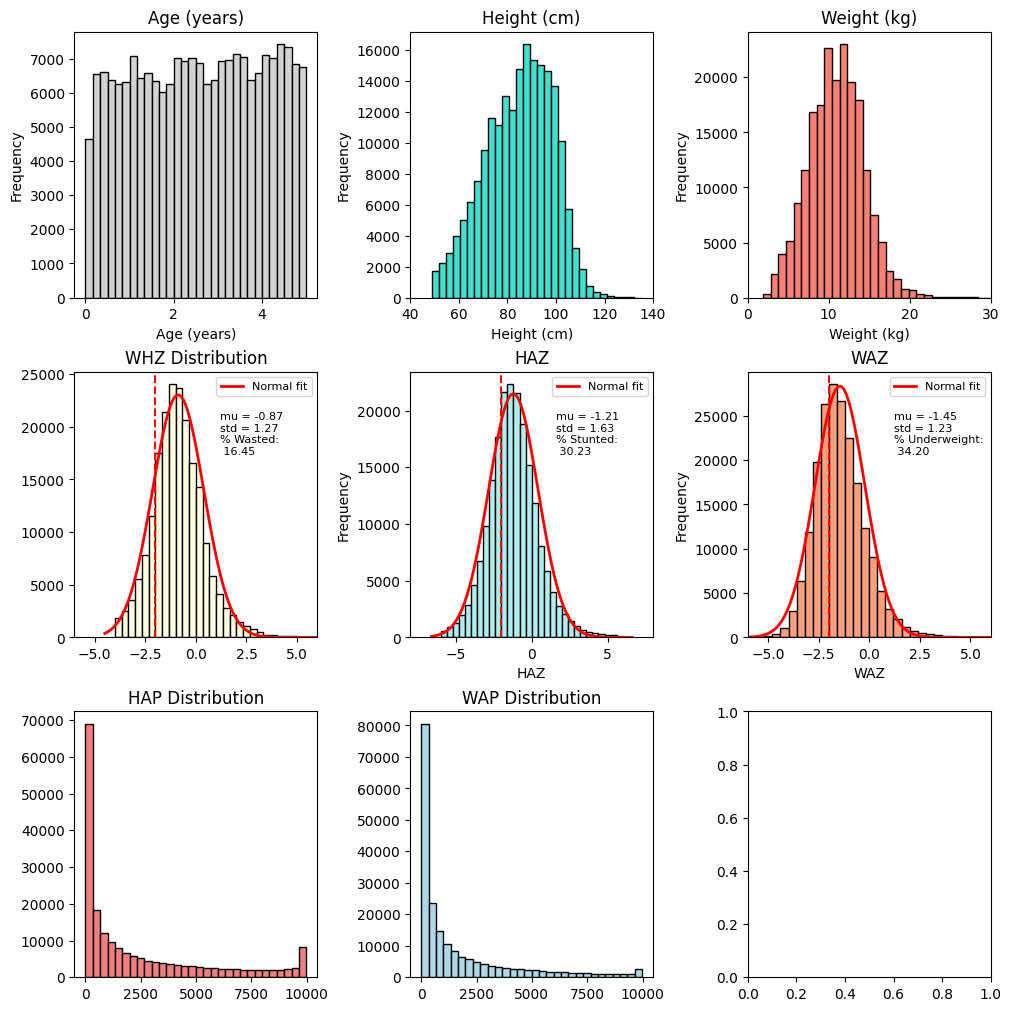

In [10]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10), constrained_layout = True)  

# Age (years)
ax[0, 0].hist(age.dropna()/365, bins=30, color='lightgray', edgecolor='black')
ax[0, 0].set_title('Age (years)')
ax[0, 0].set_xlabel('Age (years)')
ax[0, 0].set_ylabel('Frequency')

# Height distribution
ax[0, 1].hist(height.dropna(), bins=30, color='turquoise', edgecolor='black')
ax[0, 1].set_xlim([40, 140])
ax[0, 1].set_title('Height (cm)')
ax[0, 1].set_xlabel('Height (cm)')
ax[0, 1].set_ylabel('Frequency')

# Weight distribution
ax[0, 2].hist(weight.dropna(), bins=30, color='salmon', edgecolor='black')
ax[0, 2].set_xlim([0, 30])
ax[0, 2].set_title('Weight (kg)')
ax[0, 2].set_xlabel('Weight (kg)')
ax[0, 2].set_ylabel('Frequency')

# HAZ distribution
ax[1, 1].hist(haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[1, 1].set_title('HAZ')
ax[1, 1].set_xlabel('HAZ')
ax[1, 1].set_ylabel('Frequency')

# Fit normal distribution to HAZ and plot overlaying the data
haz_clean = haz.dropna()
mu, std = norm.fit(haz_clean)
xmin, xmax = ax[1, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax[1, 1].plot(x, p * len(haz_clean) * (xmax - xmin) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 1].set_xlim([-8, 8])
ax[1, 1].legend(fontsize = 8)

# WAZ distribution
ax[1, 2].hist(waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[1, 2].set_title('WAZ')
ax[1, 2].set_xlabel('WAZ')
ax[1, 2].set_ylabel('Frequency')

# Fit normal distribution to WAZ and plot overlaying the data
waz_clean = waz.dropna()
mu_waz, std_waz = norm.fit(waz_clean)
xmin_waz, xmax_waz = ax[1, 2].get_xlim()
x_waz = np.linspace(xmin_waz, xmax_waz, 100)
p_waz = norm.pdf(x_waz, mu_waz, std_waz)
ax[1, 2].plot(x_waz, p_waz * len(waz_clean) * (xmax_waz - xmin_waz) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 2].set_xlim([-6, 6])
ax[1, 2].legend(fontsize = 8)

# WHZ distribution
ax[1, 0].hist(whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[1, 0].set_title('WHZ Distribution')

# Print mean and standard deviations of fitted HAZ and WAZ distributions
print(f"HAZ Distribution: mu = {mu}, std = {std}")
print(f"WAZ Distribution: mu = {mu_waz}, std = {std_waz}")

# Fit normal distribution to WHZ and plot overlaying the data
whz_clean = whz.dropna()
mu_whz, std_whz = norm.fit(whz_clean)
xmin_whz, xmax_whz = ax[1, 0].get_xlim()
x_whz = np.linspace(xmin_whz, xmax_whz, 100)
p_whz = norm.pdf(x_whz, mu_whz, std_whz)
ax[1, 0].plot(x_whz, p_whz * len(whz_clean) * (xmax_whz - xmin_whz) / 30, 'r', linewidth=2, label='Normal fit')
ax[1, 0].set_xlim([-6, 6])
ax[1, 0].legend(fontsize = 8)

# Calculate the percentage of stunted, underweight and wasted children, based on haz < -2, waz < -2, whz < -2
percent_stunted = (haz < -2).mean() * 100
percent_underweight = (waz < -2).mean() * 100
percent_wasted = (whz < -2).mean() * 100

# Plot a vertical dashed red line at -2 in each subplot in the second row
ax[1, 0].axvline(x=-2, color='red', linestyle='--')
ax[1, 1].axvline(x=-2, color='red', linestyle='--')
ax[1, 2].axvline(x=-2, color='red', linestyle='--')

# Add text to the plot giving the mean and standard deviation of the fitted distributions, 
# and percentage of stunted, wasted and underweight children in the appropriate plots
ax[1, 1].text(0.6, 0.85, f"mu = {mu:.2f}\nstd = {std:.2f}\n% Stunted:\n {percent_stunted:.2f}", transform=ax[1, 1].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 2].text(0.6, 0.85, f"mu = {mu_waz:.2f}\nstd = {std_waz:.2f}\n% Underweight:\n {percent_underweight:.2f}", transform=ax[1, 2].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 0].text(0.6, 0.85, f"mu = {mu_whz:.2f}\nstd = {std_whz:.2f}\n% Wasted:\n {percent_wasted:.2f}", transform=ax[1, 0].transAxes, fontsize=8,
        verticalalignment='top')

# HAP distribution
ax[2, 0].hist(hap.dropna(), bins=30, color='lightcoral', edgecolor='black')
ax[2, 0].set_title('HAP Distribution')

# WAP distribution
ax[2, 1].hist(wap.dropna(), bins=30, color='lightblue', edgecolor='black')
ax[2, 1].set_title('WAP Distribution')


## Plot age, height, weight, lohr pairwise along with WHO standard

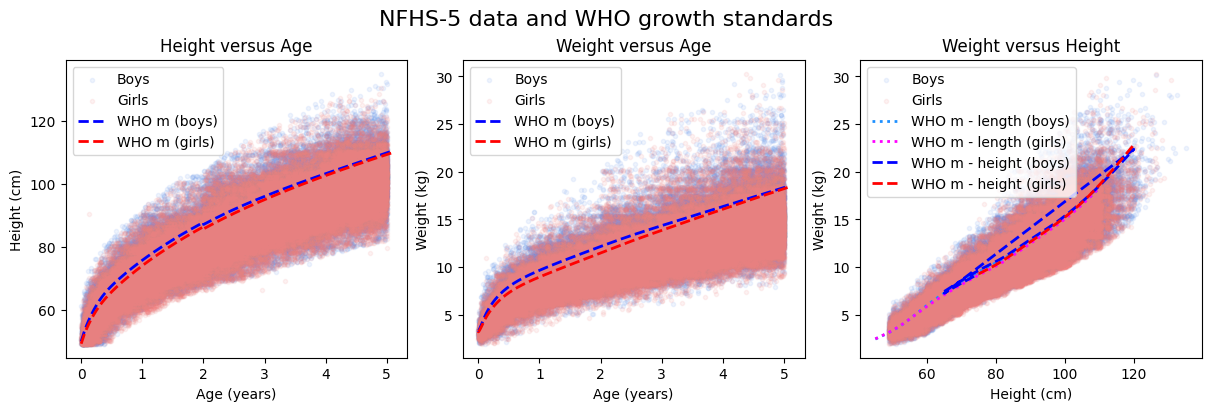

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout = True)
fig.suptitle('NFHS-5 data and WHO growth standards', fontsize=16)

# Height
boys = sex[sex == 1]
girls = sex[sex == 2]
ax[0].scatter(age[boys.index]/365, height[boys.index], color = 'cornflowerblue', marker = '.', alpha = 0.1, label = 'Boys')
ax[0].scatter(age[girls.index]/365, height[girls.index], color = 'lightcoral', marker = '.', alpha = 0.1, label = 'Girls')

# Plot m from WHO haz parameters as a function of _agedays from WHO growth standards
n_rows = len(haz_params['_agedays'])
ax[0].plot(haz_params['_agedays'][:int(n_rows/2)]/365, haz_params['m'][:int(n_rows/2)], color='b', linewidth=2, linestyle='--',
         label = 'WHO m (boys)')
ax[0].plot(haz_params['_agedays'][int(n_rows/2):] /365, haz_params['m'][int(n_rows/2):], color='r', linewidth=2, linestyle='--',
         label = 'WHO m (girls)')

ax[0].set_xlabel('Age (years)')
ax[0].set_ylabel('Height (cm)')
ax[0].set_title('Height versus Age')

ax[0].legend()

# Weight
ax[1].scatter(age[boys.index]/365, weight[boys.index], color = 'cornflowerblue', marker = '.', alpha = 0.1, label = 'Boys')
ax[1].scatter(age[girls.index]/365, weight[girls.index], color = 'lightcoral', marker = '.', alpha = 0.1, label = 'Girls')

# Plot m from WHO waz parameters as a function of _agedays from WHO growth standards
n_rows = len(waz_params['_agedays'])
ax[1].plot(waz_params['_agedays'][:int(n_rows/2)]/365, waz_params['m'][:int(n_rows/2)], color='b', linewidth=2, linestyle='--',
         label = 'WHO m (boys)')
ax[1].plot(waz_params['_agedays'][int(n_rows/2):] /365, waz_params['m'][int(n_rows/2):], color='r', linewidth=2, linestyle='--',
         label = 'WHO m (girls)')

ax[1].set_xlabel('Age (years)')
ax[1].set_ylabel('Weight (kg)')
ax[1].set_title('Weight versus Age')

ax[1].legend()

# Weight versus Height
ax[2].scatter(height[boys.index], weight[boys.index], color = 'cornflowerblue', marker = '.', alpha = 0.1, label = 'Boys')
ax[2].scatter(height[girls.index], weight[girls.index], color = 'lightcoral', marker = '.', alpha = 0.1, label = 'Girls')

# Plot m from WHO whz parameters as a function of height from WHO growth standards
n_rows = len(whz_params_lying['__000002'])
ax[2].plot(whz_params_lying['__000002'][:int(n_rows/2)], whz_params_lying['m'][:int(n_rows/2)], color='dodgerblue', linewidth=2, linestyle=':',
         label = 'WHO m - length (boys)')
ax[2].plot(whz_params_lying['__000002'][int(n_rows/2):], whz_params_lying['m'][int(n_rows/2):], color='magenta', linewidth=2, linestyle=':',
         label = 'WHO m - length (girls)')
ax[2].plot(whz_params_standing['__000003'][:int(n_rows/2)], whz_params_standing['m'][:int(n_rows/2)], color='b', linewidth=2, linestyle='--',
         label = 'WHO m - height (boys)')
ax[2].plot(whz_params_standing['__000003'][int(n_rows/2):], whz_params_standing['m'][int(n_rows/2):], color='r', linewidth=2, linestyle='--',
         label = 'WHO m - height (girls)')

ax[2].set_xlabel('Height (cm)')
ax[2].set_ylabel('Weight (kg)')
ax[2].set_title('Weight versus Height')
ax[2].legend()

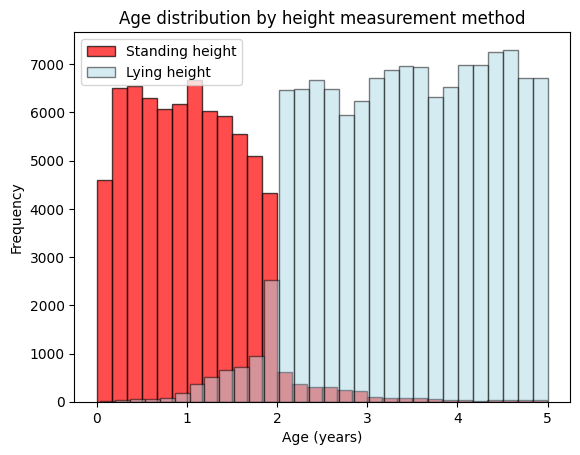

In [24]:
plt.figure()
plt.hist(age[lohr == 1]/365, bins=30, color='r', edgecolor='black', alpha = 0.7, label = 'Standing height')
plt.hist(age[lohr == 2]/365, bins=30, color='lightblue', edgecolor='black', alpha = 0.5, label = 'Lying height')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Age distribution by height measurement method')
plt.legend()

## Calculate HAZ, WAZ and WHZ from height, weight, age and sex

Calculating HAZ


199500it [00:45, 4393.50it/s]


Calculating WAZ


199500it [00:45, 4384.48it/s]


Calculating WHZ


72472it [00:06, 10391.68it/s]
126812it [00:13, 9312.66it/s] 


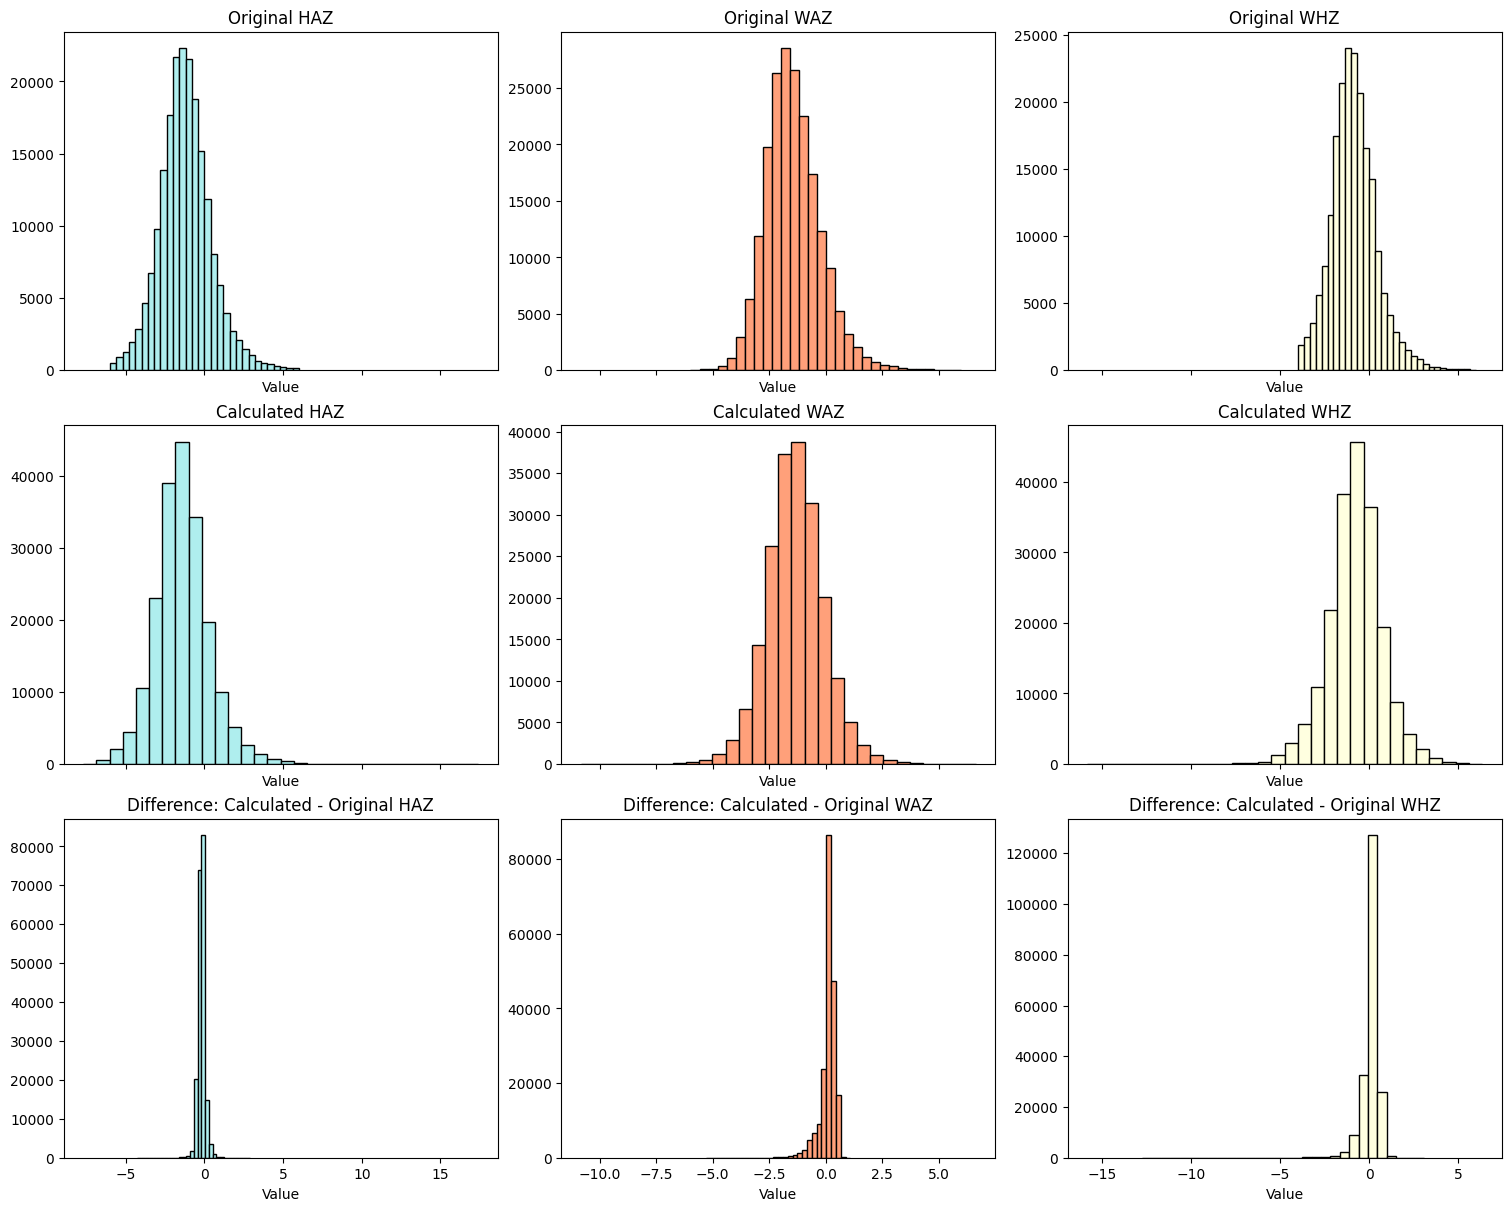

In [18]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True, sharex = 'col')

# First row: histograms of original HAZ, WAZ, WHZ
ax[0, 0].hist(haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[0, 0].set_title('Original HAZ')
ax[0, 1].hist(waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[0, 1].set_title('Original WAZ')
ax[0, 2].hist(whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[0, 2].set_title('Original WHZ')

# Second row: calculated distributions
print('Calculating HAZ')
calc_haz = ecd_nested_simulation_functions.calculate_haz(height, age, sex, haz_params)
print('Calculating WAZ')
calc_waz = ecd_nested_simulation_functions.calculate_waz(weight, age, sex, waz_params)
print('Calculating WHZ')
calc_whz = ecd_nested_simulation_functions.calculate_whz(height, weight, sex, lohr, whz_params_lying, whz_params_standing)

ax[1, 0].hist(calc_haz.dropna(), bins=30, color='paleturquoise', edgecolor='black')
ax[1, 0].set_title('Calculated HAZ')
ax[1, 1].hist(calc_waz.dropna(), bins=30, color='lightsalmon', edgecolor='black')
ax[1, 1].set_title('Calculated WAZ')
ax[1, 2].hist(calc_whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[1, 2].set_title('Calculated WHZ')

# Third row: distribution of the difference between calculated and original values
# Align indices and drop NaNs for fair comparison
haz_diff = (calc_haz - haz).dropna()
waz_diff = (calc_waz - waz).dropna()
whz_diff = (calc_whz - whz).dropna()

ax[2, 0].hist(haz_diff, bins=30, color='paleturquoise', edgecolor='black')
ax[2, 0].set_title('Difference: Calculated - Original HAZ')
ax[2, 1].hist(waz_diff, bins=30, color='lightsalmon', edgecolor='black')
ax[2, 1].set_title('Difference: Calculated - Original WAZ')
ax[2, 2].hist(whz_diff, bins=30, color='lightyellow', edgecolor='black')
ax[2, 2].set_title('Difference: Calculated - Original WHZ')

for i in range(3):
    for j in range(3):
        ax[i, j].set_xlabel('Value')

# NHTS: Jan - March 2025, 3 districts

## Load data

In [3]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
file_path ='Documents{0}CEGIS{0}DiscSim_figures_and_data{0}NHTS_JantoMarch_3districts.csv'.format(sep)
nhts_data = pd.read_csv(file_path)
nhts_data

/var/folders/q7/70vh4qvd49b25t1d4t3xd85m0000gp/T/ipykernel_3186/2654172405.py:2: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  nhts_data = pd.read_csv(file_path)


,D_ID,D_Name,Proj_ID,Proj_Name,Sec_ID,Sec_Name,AWC_ID,AWC_Name,IdChild,Gender,...,AWT_Weightdate,Month,Height,Weight,sex,age_months,haz06,waz06,whz06,bmiz06
0,15.0,KAMAREDDY,1501,BANSWADA,150101,Banswada,1802001,Banswada-1,8443374.0,female,...,07mar2025,March,86.2,12.0,2.0,34.694045,-2.12,-1.00,0.29,0.54
1,15.0,KAMAREDDY,1501,BANSWADA,150101,Banswada,1802001,Banswada-1,8857882.0,male,...,08mar2025,March,90.3,11.6,1.0,39.687885,-2.10,-2.09,-1.40,-1.08
2,15.0,KAMAREDDY,1501,BANSWADA,150101,Banswada,1802001,Banswada-1,7775893.0,male,...,04mar2025,March,83.3,10.4,1.0,27.564682,-2.07,-1.82,-0.99,-0.75
3,15.0,KAMAREDDY,1501,BANSWADA,150101,Banswada,1802001,Banswada-1,6917391.0,female,...,07mar2025,March,84.3,11.8,2.0,31.408624,-2.07,-0.76,0.56,0.80
4,15.0,KAMAREDDY,1501,BANSWADA,150101,Banswada,1802001,Banswada-1,7443585.0,female,...,08mar2025,March,82.6,9.8,2.0,23.425051,-1.03,-1.22,-0.95,-0.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444876,2.0,KUMARAMBHEEM-ASIFABAD,205,WANKDI,20507,INDHANI,1915157,Jambuldhari,7541354.0,male,...,10feb2025,Feb,94,13.6,1.0,41.954825,-1.47,-0.98,-0.20,-0.04
444877,2.0,KUMARAMBHEEM-ASIFABAD,205,WANKDI,20507,INDHANI,1915157,Jambuldhari,5762183.0,male,...,10feb2025,Feb,99,14,1.0,52.533881,-1.57,-1.55,-0.92,-0.81
444878,2.0,KUMARAMBHEEM-ASIFABAD,205,WANKDI,20507,INDHANI,1915157,Jambuldhari,5629082.0,female,...,10feb2025,Feb,98,14.5,2.0,53.683778,-1.77,-1.18,-0.13,-0.11
444879,2.0,KUMARAMBHEEM-ASIFABAD,205,WANKDI,20507,INDHANI,1915157,Jambuldhari,5629121.0,female,...,10feb2025,Feb,102,15.2,2.0,54.603696,-0.99,-0.90,-0.44,-0.46


## Processing

In [5]:
# Remove rows for which haz, waz or whz is 99
nhts_data = nhts_data[(nhts_data['haz06'] != 99) & (nhts_data['waz06'] != 99) & (nhts_data['whz06'] != 99)]

# Remove rows for which age, height, weight or sex is NaN
nhts_data = nhts_data.dropna(subset=['age_months', 'Height', 'Weight', 'Gender'])

## Get data into lists

In [6]:
age_months = nhts_data['age_months']
weight = nhts_data['Weight']
weight = pd.to_numeric(weight, errors='coerce')
height = nhts_data['Height']
height = pd.to_numeric(height, errors='coerce')
haz = nhts_data['haz06']
waz = nhts_data['waz06']
whz = nhts_data['whz06']
sex = nhts_data['Gender'].replace({'male': 1, 'female': 2})


/var/folders/q7/70vh4qvd49b25t1d4t3xd85m0000gp/T/ipykernel_3186/1683783418.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sex = nhts_data['Gender'].replace({'male': 1, 'female': 2})


In [7]:
# Print minimum, maximum, mean and standard deviation of age, height, weight, haz, waz and whz.
print("Age: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(age_months), np.max(age_months), np.mean(age_months), np.std(age_months)))
print("Height: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(height), np.max(height), np.mean(height), np.std(height)))
print("Weight: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(weight), np.max(weight), np.mean(weight), np.std(weight)))
print("HAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(haz), np.max(haz), np.mean(haz), np.std(haz)))
print("WAZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(waz), np.max(waz), np.mean(waz), np.std(waz)))
print("WHZ: Min = {}, Max = {}, Mean = {}, Std = {}".format(np.min(whz), np.max(whz), np.mean(whz), np.std(whz)))


Age: Min = 0.0, Max = 60.97741273100616, Mean = 30.647499906360757, Std = 16.86619288330363
Height: Min = 45.0, Max = 120.0, Mean = 83.48938549756183, Std = 13.611203611863958
Weight: Min = 1.1, Max = 25.0, Mean = 10.997486906266934, Std = 3.032738849111477
HAZ: Min = -13.04, Max = 25.42, Mean = -1.7750370913852265, Std = 1.285920168751297
WAZ: Min = -8.59, Max = 17.67, Mean = -1.247076508036843, Std = 0.9337208190476067
WHZ: Min = -11.01, Max = 27.79, Mean = -0.2913047227740654, Std = 1.1937621359292419


## Plot data

Text(0.6, 0.85, '% Wasted:\n 2.85')

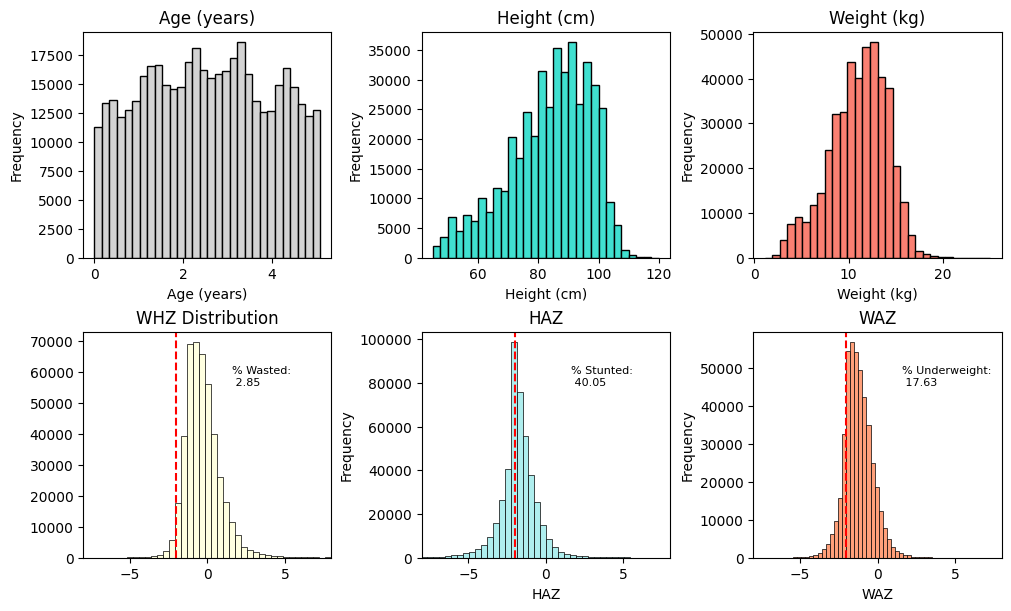

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6), constrained_layout = True)  

# Age (years)
ax[0, 0].hist(age_months.dropna()/12, bins=30, color='lightgray', edgecolor='black')
ax[0, 0].set_title('Age (years)')
ax[0, 0].set_xlabel('Age (years)')
ax[0, 0].set_ylabel('Frequency')

# Height distribution
ax[0, 1].hist(height.dropna(), bins=30, color='turquoise', edgecolor='black')
ax[0, 1].set_title('Height (cm)')
ax[0, 1].set_xlabel('Height (cm)')
ax[0, 1].set_ylabel('Frequency')

# Weight distribution
ax[0, 2].hist(weight.dropna(), bins=30, color='salmon', edgecolor='black')
ax[0, 2].set_title('Weight (kg)')
ax[0, 2].set_xlabel('Weight (kg)')
ax[0, 2].set_ylabel('Frequency')

# HAZ distribution
ax[1, 1].hist(haz.dropna(), bins=100, color='paleturquoise', edgecolor='black', linewidth=0.5)
ax[1, 1].set_xlim([-8, 8])
ax[1, 1].set_title('HAZ')
ax[1, 1].set_xlabel('HAZ')
ax[1, 1].set_ylabel('Frequency')

# WAZ distribution
ax[1, 2].hist(waz.dropna(), bins=100, color='lightsalmon', edgecolor='black', linewidth = 0.5)
ax[1, 2].set_xlim([-8, 8])
ax[1, 2].set_title('WAZ')
ax[1, 2].set_xlabel('WAZ')
ax[1, 2].set_ylabel('Frequency')

# WHZ distribution
ax[1, 0].hist(whz.dropna(), bins=100, color='lightyellow', edgecolor='black', linewidth=0.5)
ax[1, 0].set_xlim([-8, 8])
ax[1, 0].set_title('WHZ Distribution')

# Calculate the percentage of stunted, underweight and wasted children, based on haz < -2, waz < -2, whz < -2
percent_stunted = (haz < -2).mean() * 100
percent_underweight = (waz < -2).mean() * 100
percent_wasted = (whz < -2).mean() * 100

# Plot a vertical dashed red line at -2 in each subplot in the second row
ax[1, 0].axvline(x=-2, color='red', linestyle='--')
ax[1, 1].axvline(x=-2, color='red', linestyle='--')
ax[1, 2].axvline(x=-2, color='red', linestyle='--')

# Add text to the plot giving the mean and standard deviation of the fitted distributions, 
# and percentage of stunted, wasted and underweight children in the appropriate plots
ax[1, 1].text(0.6, 0.85, f"% Stunted:\n {percent_stunted:.2f}", transform=ax[1, 1].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 2].text(0.6, 0.85, f"% Underweight:\n {percent_underweight:.2f}", transform=ax[1, 2].transAxes, fontsize=8,
        verticalalignment='top')
ax[1, 0].text(0.6, 0.85, f"% Wasted:\n {percent_wasted:.2f}", transform=ax[1, 0].transAxes, fontsize=8,
        verticalalignment='top')


## Calculate HAZ, WAZ and WHZ and check against data

Calculating HAZ


50148it [00:08, 5873.28it/s]


KeyboardInterrupt: 

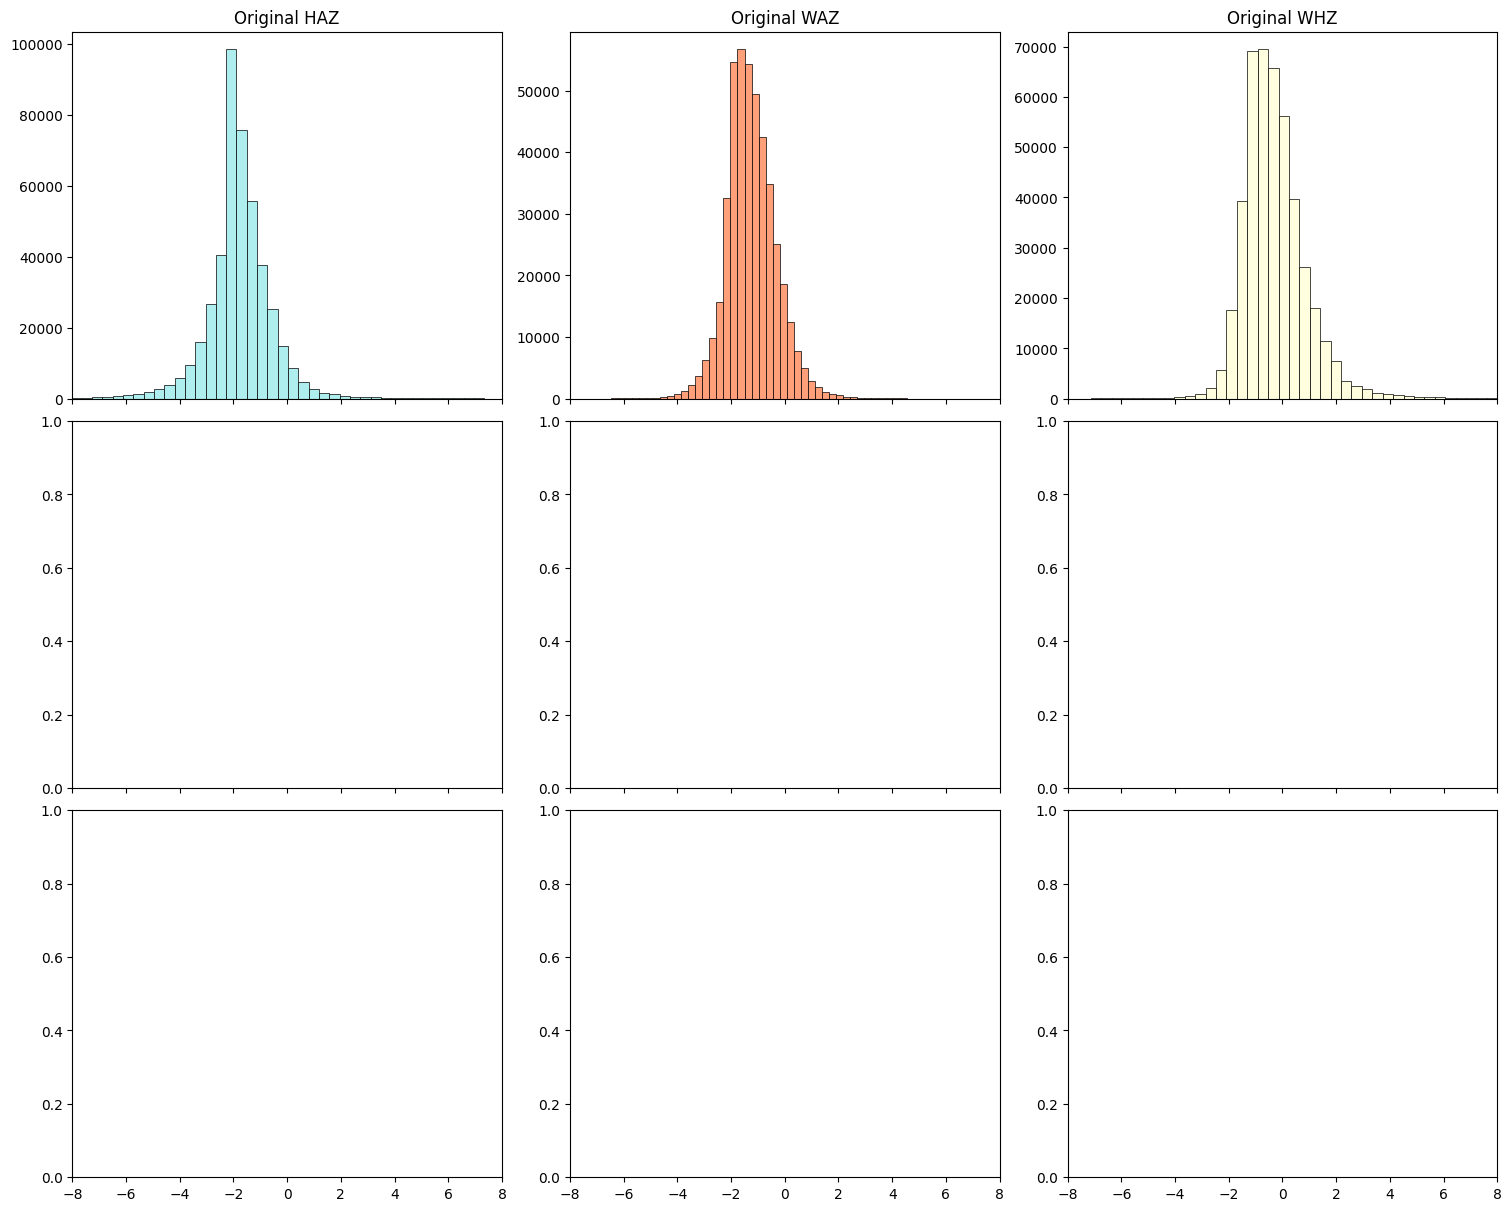

In [198]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True, sharex = 'col')

# First row: histograms of original HAZ, WAZ, WHZ
ax[0, 0].hist(haz.dropna(), bins=100, color='paleturquoise', edgecolor='black', linewidth=0.5)
ax[0, 0].set_xlim([-8, 8])
ax[0, 0].set_title('Original HAZ')
ax[0, 1].hist(waz.dropna(), bins=100, color='lightsalmon', edgecolor='black', linewidth=0.5)
ax[0, 1].set_xlim([-8, 8])
ax[0, 1].set_title('Original WAZ')
ax[0, 2].hist(whz.dropna(), bins=100, color='lightyellow', edgecolor='black', linewidth=0.5)
ax[0, 2].set_xlim([-8, 8])
ax[0, 2].set_title('Original WHZ')

# Second row: calculated distributions
age_days = (age_months.dropna()/12*365).astype(int)
print('Calculating HAZ')
calc_haz = ecd_nested_simulation_functions.calculate_haz(height.dropna(), age_days, sex.dropna(), haz_params)
print('Calculating WAZ')
calc_waz = ecd_nested_simulation_functions.calculate_waz(weight.dropna(), age_days, sex.dropna(), waz_params)
print('Calculating WHZ')
lohr = pd.Series(np.where(age_days < 2*365, 1, 2), index=age_days.index) # 1 for age_months < 24, 2 if age_months >= 24
calc_whz = ecd_nested_simulation_functions.calculate_whz(height.dropna(), weight.dropna(), sex.dropna(), lohr, whz_params_lying, whz_params_standing)

ax[1, 0].hist(calc_haz.dropna(), bins=100, color='paleturquoise', edgecolor='black', linewidth=0.5)
ax[1, 0].set_xlim([-8, 8])
ax[1, 0].set_title('Calculated HAZ')
ax[1, 1].hist(calc_waz.dropna(), bins=100, color='lightsalmon', edgecolor='black', linewidth=0.5)
ax[1, 1].set_xlim([-8, 8])
ax[1, 1].set_title('Calculated WAZ')
ax[1, 2].hist(calc_whz.dropna(), bins=100, color='lightyellow', edgecolor='black', linewidth=0.5)
ax[1, 2].set_xlim([-8, 8])
ax[1, 2].set_title('Calculated WHZ')

# Third row: distribution of the difference between calculated and original values
# Align indices and drop NaNs for fair comparison
haz_diff = (calc_haz - haz).dropna()
waz_diff = (calc_waz - waz).dropna()
whz_diff = (calc_whz - whz).dropna()

ax[2, 0].hist(haz_diff, bins=100, color='paleturquoise', edgecolor='black', linewidth=0.5)
ax[2, 0].set_title('Difference: Calculated - Original HAZ')
ax[2, 1].hist(waz_diff, bins=100, color='lightsalmon', edgecolor='black', linewidth=0.5)
ax[2, 1].set_title('Difference: Calculated - Original WAZ')
ax[2, 2].hist(whz_diff, bins=100, color='lightyellow', edgecolor='black', linewidth=0.5)
ax[2, 2].set_title('Difference: Calculated - Original WHZ')

for i in range(3):
    for j in range(3):
        ax[i, j].set_xlabel('Value')

## Generate normal distributions with same % stunting, underweight and wasting

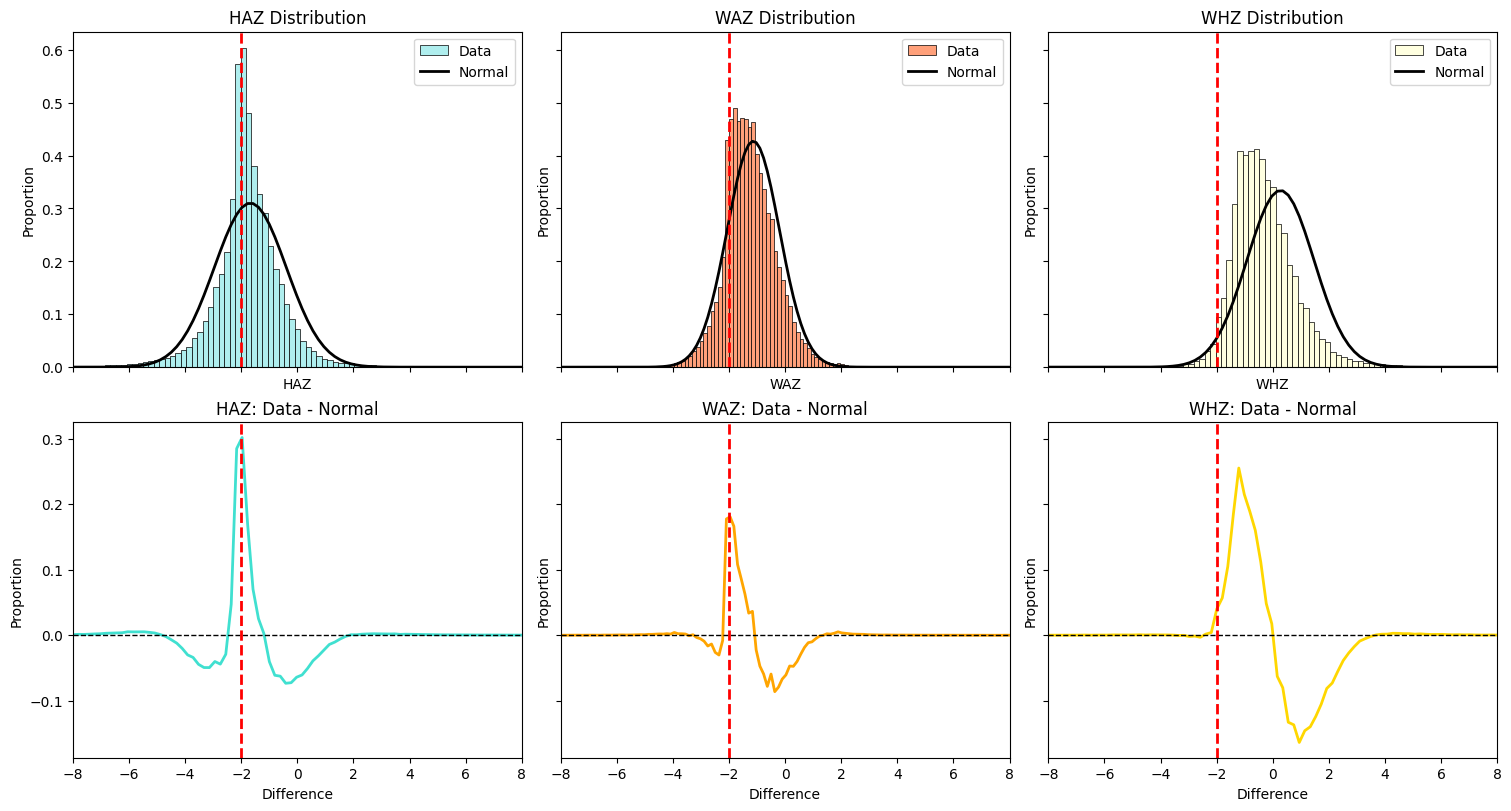

In [11]:
# Use the real % stunting, wasting and underweight in the NHTS data to generate normal distributions and overlay them on the data
nbins = 200

# Calculate means for normal distributions based on observed % stunted, underweight, wasted
haz_std = np.std(haz.dropna())
waz_std = np.std(waz.dropna())
whz_std = np.std(whz.dropna())

haz_mean = -2 - norm.ppf(percent_stunted / 100) * haz_std
waz_mean = -2 - norm.ppf(percent_underweight / 100) * waz_std
whz_mean = -2 - norm.ppf(percent_wasted / 100) * whz_std

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True, sharex = 'col', sharey = 'row')

# HAZ
haz_data = haz.dropna()
haz_bins = np.linspace(haz_data.min(), haz_data.max(), nbins)
haz_hist, _ = np.histogram(haz_data, bins=haz_bins, density=True)
haz_bin_centers = (haz_bins[:-1] + haz_bins[1:]) / 2
axes[0, 0].hist(haz_data, bins=haz_bins, density=True, color='paleturquoise', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
x_haz = np.linspace(haz_data.min(), haz_data.max(), nbins - 1)
axes[0, 0].plot(x_haz, norm.pdf(x_haz, haz_mean, haz_std), 'k-', lw=2, label='Normal')
axes[0, 0].set_xlim([-8, 8])
axes[0, 0].axvline(-2, color='red', linestyle='--', linewidth = 2)
axes[0, 0].set_title('HAZ Distribution')
axes[0, 0].set_xlabel('HAZ')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].legend()

# WAZ
waz_data = waz.dropna()
waz_bins = np.linspace(waz_data.min(), waz_data.max(), nbins)
waz_hist, _ = np.histogram(waz_data, bins=waz_bins, density=True)
axes[0, 1].hist(waz_data, bins=waz_bins, density=True, color='lightsalmon', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
x_waz = np.linspace(waz_data.min(), waz_data.max(), nbins - 1)
axes[0, 1].plot(x_waz, norm.pdf(x_waz, waz_mean, waz_std), 'k-', lw=2, label='Normal')
axes[0, 1].set_xlim([-8, 8])
axes[0, 1].axvline(-2, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('WAZ Distribution')
axes[0, 1].set_xlabel('WAZ')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].legend()

# WHZ
whz_data = whz.dropna()
whz_bins = np.linspace(whz_data.min(), whz_data.max(), nbins)
whz_hist, _ = np.histogram(whz_data, bins=whz_bins, density=True)
axes[0, 2].hist(whz_data, bins=whz_bins, density=True, color='lightyellow', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
axes[0, 2].set_xlim([-8, 8])
x_whz = np.linspace(whz_data.min(), whz_data.max(), nbins - 1)
axes[0, 2].plot(x_whz, norm.pdf(x_whz, whz_mean, whz_std), 'k-', lw=2, label='Normal')
axes[0, 2].axvline(-2, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('WHZ Distribution')
axes[0, 2].set_xlabel('WHZ')
axes[0, 2].set_ylabel('Proportion')
axes[0, 2].legend()

axes[1, 0].plot(x_haz, haz_hist - norm.pdf(x_haz, haz_mean, haz_std), color = 'turquoise', linewidth=2)
axes[1, 0].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 0].set_title('HAZ: Data - Normal')
axes[1, 0].set_xlabel('Difference')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].axvline(-2, color='red', linestyle='--', linewidth=2)

axes[1, 1].plot(x_waz, waz_hist - norm.pdf(x_waz, waz_mean, waz_std), color = 'orange', linewidth=2)
axes[1, 1].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 1].set_title('WAZ: Data - Normal')
axes[1, 1].set_xlabel('Difference')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].axvline(-2, color='red', linestyle='--', linewidth=2)

axes[1, 2].plot(x_whz, whz_hist - norm.pdf(x_whz, whz_mean, whz_std), color = 'gold', linewidth=2)
axes[1, 2].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 2].set_title('WHZ: Data - Normal')
axes[1, 2].set_xlabel('Difference')
axes[1, 2].set_ylabel('Proportion')
axes[1, 2].axvline(-2, color='red', linestyle='--', linewidth=2)

## Generate normal distribution with higher (realistic) % stunting, wasting, underweight

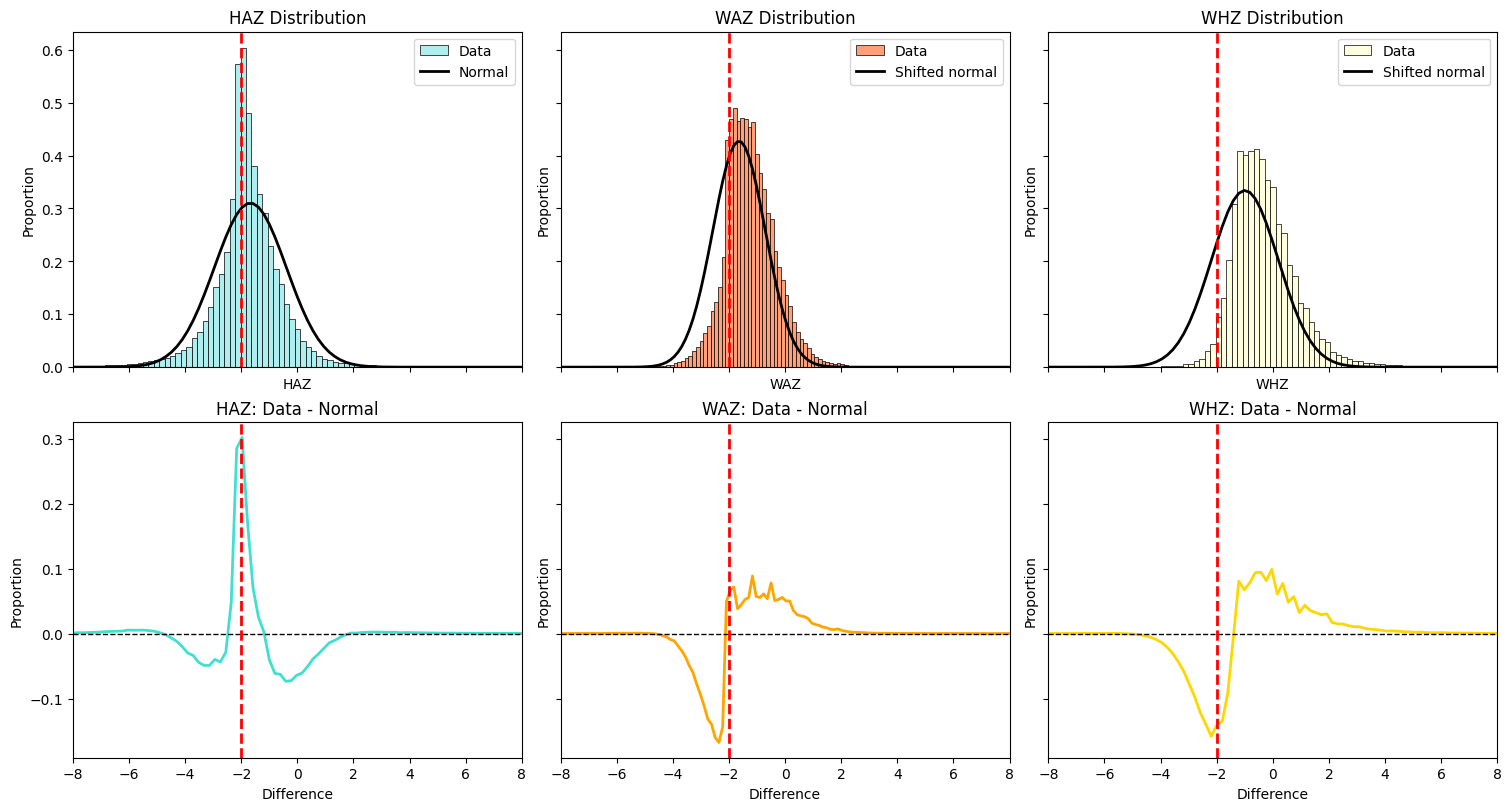

In [12]:
# Use the real % stunting, wasting and underweight in the NHTS data to generate normal distributions and overlay them on the data
nbins = 200

# Calculate means for normal distributions based on observed % stunted, underweight, wasted
haz_std = np.std(haz.dropna())
waz_std = np.std(waz.dropna())
whz_std = np.std(whz.dropna())

haz_mean = -2 - norm.ppf(40 / 100) * haz_std
waz_mean = -2 - norm.ppf(35 / 100) * waz_std
whz_mean = -2 - norm.ppf(20 / 100) * whz_std

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True, sharex = 'col', sharey = 'row')

# HAZ
haz_data = haz.dropna()
haz_bins = np.linspace(haz_data.min(), haz_data.max(), nbins)
haz_hist, _ = np.histogram(haz_data, bins=haz_bins, density=True)
haz_bin_centers = (haz_bins[:-1] + haz_bins[1:]) / 2
axes[0, 0].hist(haz_data, bins=haz_bins, density=True, color='paleturquoise', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
x_haz = np.linspace(haz_data.min(), haz_data.max(), nbins - 1)
axes[0, 0].plot(x_haz, norm.pdf(x_haz, haz_mean, haz_std), 'k-', lw=2, label='Normal')
axes[0, 0].set_xlim([-8, 8])
axes[0, 0].axvline(-2, color='red', linestyle='--', linewidth = 2)
axes[0, 0].set_title('HAZ Distribution')
axes[0, 0].set_xlabel('HAZ')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].legend()

# WAZ
waz_data = waz.dropna()
waz_bins = np.linspace(waz_data.min(), waz_data.max(), nbins)
waz_hist, _ = np.histogram(waz_data, bins=waz_bins, density=True)
axes[0, 1].hist(waz_data, bins=waz_bins, density=True, color='lightsalmon', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
x_waz = np.linspace(waz_data.min(), waz_data.max(), nbins - 1)
axes[0, 1].plot(x_waz, norm.pdf(x_waz, waz_mean, waz_std), 'k-', lw=2, label='Shifted normal')
axes[0, 1].set_xlim([-8, 8])
axes[0, 1].axvline(-2, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('WAZ Distribution')
axes[0, 1].set_xlabel('WAZ')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].legend()

# WHZ
whz_data = whz.dropna()
whz_bins = np.linspace(whz_data.min(), whz_data.max(), nbins)
whz_hist, _ = np.histogram(whz_data, bins=whz_bins, density=True)
axes[0, 2].hist(whz_data, bins=whz_bins, density=True, color='lightyellow', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
axes[0, 2].set_xlim([-8, 8])
x_whz = np.linspace(whz_data.min(), whz_data.max(), nbins - 1)
axes[0, 2].plot(x_whz, norm.pdf(x_whz, whz_mean, whz_std), 'k-', lw=2, label='Shifted normal')
axes[0, 2].axvline(-2, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('WHZ Distribution')
axes[0, 2].set_xlabel('WHZ')
axes[0, 2].set_ylabel('Proportion')
axes[0, 2].legend()

axes[1, 0].plot(x_haz, haz_hist - norm.pdf(x_haz, haz_mean, haz_std), color = 'turquoise', linewidth=2)
axes[1, 0].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 0].set_title('HAZ: Data - Normal')
axes[1, 0].set_xlabel('Difference')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].axvline(-2, color='red', linestyle='--', linewidth=2)

axes[1, 1].plot(x_waz, waz_hist - norm.pdf(x_waz, waz_mean, waz_std), color = 'orange', linewidth=2)
axes[1, 1].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 1].set_title('WAZ: Data - Normal')
axes[1, 1].set_xlabel('Difference')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].axvline(-2, color='red', linestyle='--', linewidth=2)

axes[1, 2].plot(x_whz, whz_hist - norm.pdf(x_whz, whz_mean, whz_std), color = 'gold', linewidth=2)
axes[1, 2].axhline(0, color = 'k', linestyle = '--', linewidth = 1)
axes[1, 2].set_title('WHZ: Data - Normal')
axes[1, 2].set_xlabel('Difference')
axes[1, 2].set_ylabel('Proportion')
axes[1, 2].axvline(-2, color='red', linestyle='--', linewidth=2)

## Test algorithms to generate 'distorted' WAZ distribution from shifted normal

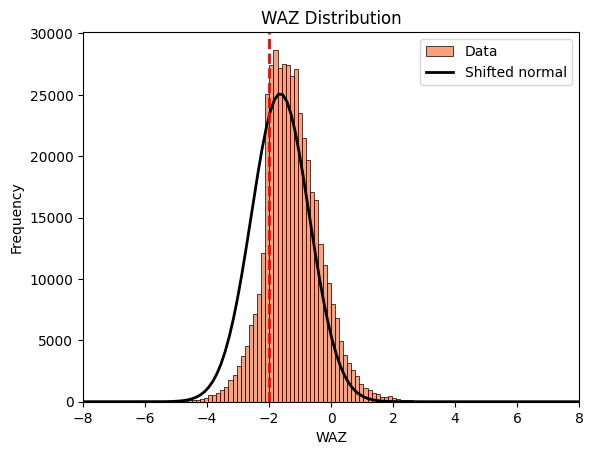

In [214]:
# WAZ
plt.figure()
waz_data = waz.dropna()
waz_bins = np.linspace(waz_data.min(), waz_data.max(), nbins)
waz_hist, _ = np.histogram(waz_data, bins=waz_bins, density=False)
plt.hist(waz_data, bins=waz_bins, density=False, color='lightsalmon', alpha=1, label='Data', edgecolor='black', linewidth=0.5)
x_waz = np.linspace(waz_data.min(), waz_data.max(), nbins - 1)
bin_width = x_waz[1] - x_waz[0]
normal_freq = norm.pdf(x_waz, waz_mean, waz_std) * len(waz_data) * bin_width
plt.plot(x_waz, normal_freq, 'k-', lw=2, label='Shifted normal')
plt.xlim([-8, 8])
plt.axvline(-2, color='red', linestyle='--', linewidth=2)
plt.title('WAZ Distribution')
plt.xlabel('WAZ')
plt.ylabel('Frequency')
plt.legend()

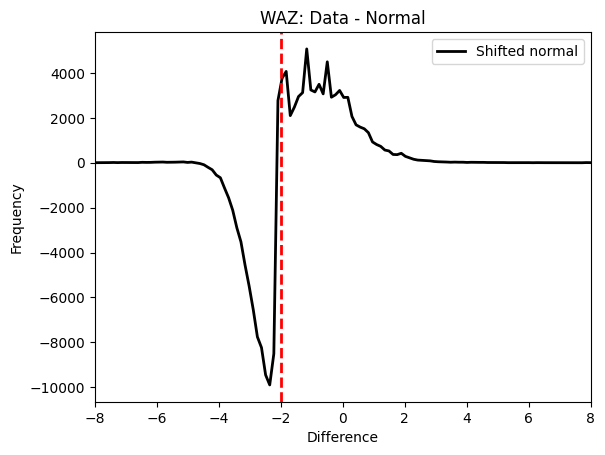

In [215]:
# WAZ
plt.figure()
plt.plot(x_waz, waz_hist - normal_freq, 'k-', lw=2, label='Shifted normal')
plt.xlim([-8, 8])
plt.axvline(-2, color='red', linestyle='--', linewidth=2)
plt.title('WAZ: Data - Normal')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.legend()

Text(0.5, 1.0, 'WAZ: Data vs. Generated Normal Distribution')

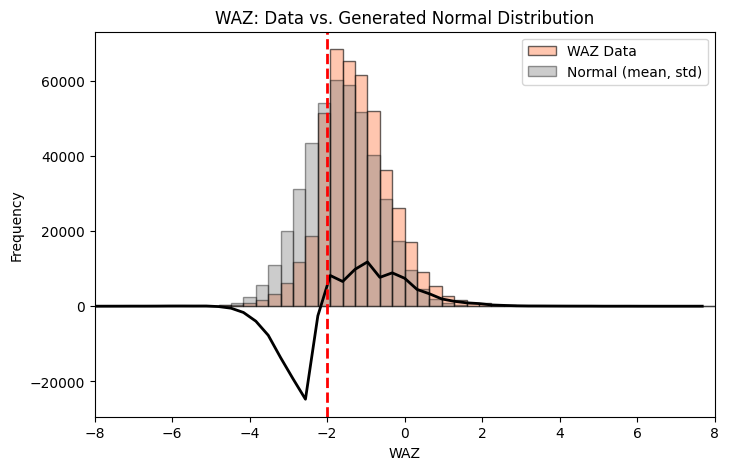

In [209]:
# Generate values from the normal distribution and plot with data using the same bin edges
waz_data = waz.dropna()
normal_waz = np.random.normal(waz_mean, waz_std, len(waz_data))

bins = np.linspace(-8, 8, 51)  # 50 bins from -8 to 8

plt.figure(figsize=(8, 5))
waz_hist, _ = np.histogram(waz_data, bins=bins, density=False)
plt.hist(waz_data, bins=bins, color='lightsalmon', alpha=0.6, label='WAZ Data', edgecolor='black')
normal_hist, _ = np.histogram(normal_waz, bins=bins, density=False)
plt.hist(normal_waz, bins=bins, color='gray', alpha=0.4, label='Normal (mean, std)', edgecolor='black')
plt.plot(bins[:-1], waz_hist - normal_hist, 'k-', lw=2)  # Line plot for normal distribution histogram
plt.axvline(-2, color='red', linestyle='--', linewidth=2)
plt.legend()
plt.xlim([-8, 8])
plt.xlabel('WAZ')
plt.ylabel('Frequency')
plt.title('WAZ: Data vs. Generated Normal Distribution')



Text(0.5, 1.0, 'WAZ: Data vs. Bunched Distribution')

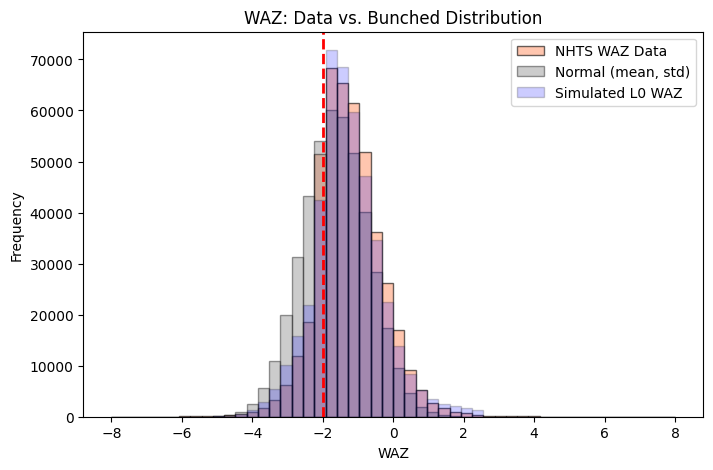

In [218]:
threshold = -2
original_data = pd.Series(normal_waz)
percent_below_threshold_original = (normal_waz < threshold).mean() * 100
percent_below_threshold_bunched = (waz_data < threshold).mean() * 100

bunched_waz = generate_bunched_data(threshold, original_data, percent_below_threshold_original, 
                                                                    percent_below_threshold_bunched,
                          bunch_factor = 0.05, bin_size = 0.1)


# Plot the real and bunched waz distributions with the same bins
bins = np.linspace(-8, 8, 51)  # 50 bins from -8 to 8

plt.figure(figsize=(8, 5))
plt.hist(waz_data, bins=bins, color='lightsalmon', alpha=0.6, label='NHTS WAZ Data', edgecolor='black')
plt.hist(normal_waz, bins=bins, color='gray', alpha=0.4, label='Normal (mean, std)', edgecolor='black')
plt.hist(bunched_waz, bins=bins, color='blue', alpha=0.2, label='Simulated L0 WAZ', edgecolor='black',)
plt.axvline(-2, color='red', linestyle='--', linewidth=2)
plt.legend()
#plt.xlim([-8, 8])
plt.xlabel('WAZ')
plt.ylabel('Frequency')
plt.title('WAZ: Data vs. Bunched Distribution')


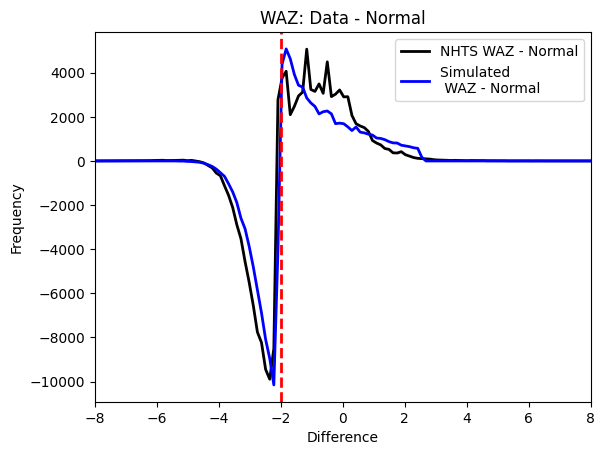

In [219]:
bunched_waz_hist, _ = np.histogram(bunched_waz, bins=waz_bins, density=False)

plt.figure()
plt.plot(x_waz, waz_hist - normal_freq, 'k-', lw=2, label='NHTS WAZ - Normal')
plt.plot(x_waz, bunched_waz_hist - normal_freq, color='blue', linewidth=2, label='Simulated \n WAZ - Normal')
plt.xlim([-8, 8])
plt.axvline(-2, color='red', linestyle='--', linewidth=2)
plt.title('WAZ: Data - Normal')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.legend()

In [188]:
def generate_bunched_data(threshold, original_data, percent_below_threshold_original, percent_below_threshold_bunched,
                          bunch_factor = 0.5, bin_size = 0.1):
    """
    Distort the original data by applying a bunching effect around the threshold.
    Args:
        threshold (float): The threshold value for bunching.
        original_data (pd.Series): The original data to be distorted.
        percent_below_threshold_original (float): The percentage of data below the threshold in the original data.
        percent_below_threshold_bunched (float): The desired percentage of data below the threshold in the bunched data.
        bunch_factor (float): Float between 0 and 1 (exclusive) which gives the intensity of bunching (closer to 1 means more bunching).
        bin_size (float): The size of the bins for bunching.
    """
    bunched_data = original_data.copy()
    
    # Divide the range of the data into bins of size bin_size
    bins = np.arange(original_data.min(), original_data.max() + bin_size, bin_size)
    binned_data = pd.cut(original_data, bins=bins, include_lowest=True)

    # Calculate percentage of points to be shifted above threshold from each bin
    percent_shift = 100 * (1 - percent_below_threshold_bunched/percent_below_threshold_original)

    # In each bin below the threshold, choose a random subset of points (percent_shift % from each bin)
    shift_indices = []
    for bin in binned_data.cat.categories:
        if bin.right <= threshold:
            # Find the number of data points in this bin
            n_points = (binned_data == bin).sum()
            # Calculate the number of points to shift
            n_shift = int(n_points * percent_shift/100)
            # Choose random points to shift and get their indices in bunched_data
            shift_points = bunched_data[binned_data == bin].sample(n=n_shift, replace=False)
            shift_indices.extend(shift_points.index)

    # Assign exponentially decreasing probabilities to each bin above the threshold based on the bunch factor
    probabilities = []
    bins_above_threshold = [b for b in binned_data.cat.categories if b.left > threshold]
    for i, bin in enumerate(bins_above_threshold):
        prob = (1 - bunch_factor) ** i
        probabilities.append(prob)

    # Normalize probabilities to sum to 1
    probabilities = np.array(probabilities)
    probabilities /= probabilities.sum()

    # For each point to be shifted, choose a bin above the threshold based on the probabilities
    for idx in shift_indices:
        chosen_bin = np.random.choice(bins_above_threshold, p=probabilities)
        # Choose a random point from the chosen bin and assign it to the bunched data
        bunched_data.loc[idx] = np.random.uniform(chosen_bin.left, chosen_bin.right)

    return bunched_data

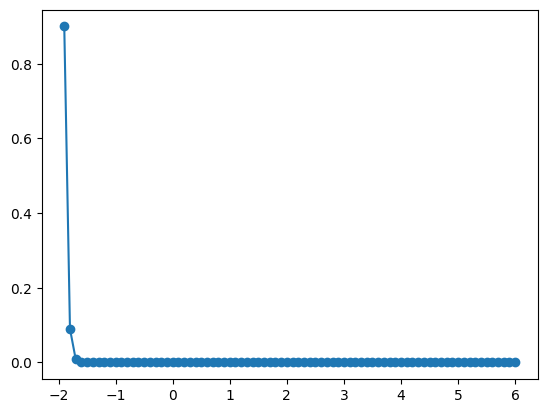

In [164]:
threshold = -2
max_waz = 6
bin_size = 0.1
bins_above_threshold = np.arange(threshold + bin_size, max_waz + bin_size, bin_size)
bunch_factor = 0.1

# Assign exponentially decreasing probabilities to each bin above the threshold based on the bunch factor
probabilities = []
for i, bin in enumerate(bins_above_threshold):
    prob = bunch_factor ** i
    probabilities.append(prob)

# Normalize probabilities to sum to 1
probabilities = np.array(probabilities)
probabilities /= probabilities.sum()

plt.figure()
plt.plot(bins_above_threshold, probabilities, marker='o')

# Anthropometric measures: WHO parameters

In [50]:
cd Documents/

/Users/amritasingh/Documents


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [51]:
# Load HAZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}lenanthro.dta'.format(os.sep)
haz_params = extract_data_from_dta(filename)

# Load WAZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}weianthro.dta'.format(os.sep)
waz_params = extract_data_from_dta(filename)

# Load WHZ parameters
filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}wfhanthro.dta'.format(os.sep)
whz_params_standing = extract_data_from_dta(filename)

filename = 'CEGIS{0}igrowup_WHO{0}igrowup_update{0}wflanthro.dta'.format(os.sep)
whz_params_lying = extract_data_from_dta(filename)

Text(0.5, 1.0, 'WHO growth standards: Length or height versus age')

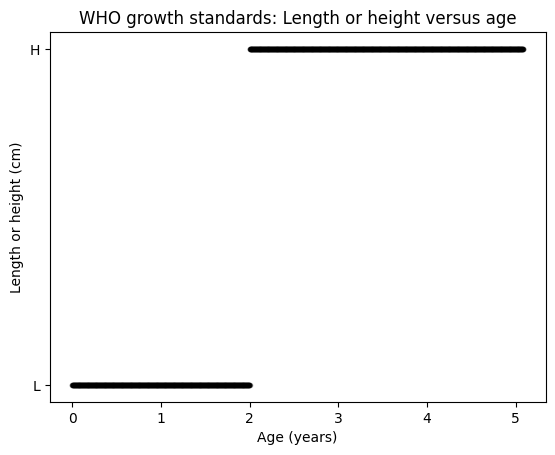

In [37]:
plt.figure()
plt.scatter(haz_params['_agedays']/365, haz_params['loh'], color = 'k', marker = '.', alpha = 0.2)
plt.xlabel('Age (years)')
plt.ylabel('Length or height (cm)')
plt.title('WHO growth standards: Length or height versus age')

In [73]:
len(np.unique(haz_params['_agedays']))

1857

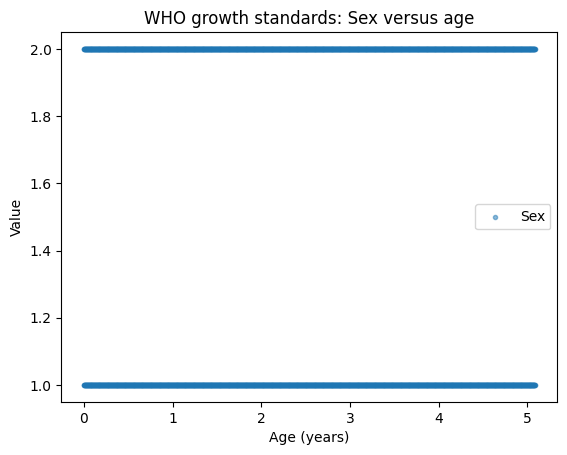

In [42]:
plt.figure()
plt.scatter(haz_params['_agedays']/365, haz_params['__000001'], label = 'Sex', alpha = 0.5, marker = '.')
plt.xlabel('Age (years)')
plt.ylabel('Value')
plt.title('WHO growth standards: Sex versus age')
plt.legend()